In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Dataset Loaded")

100%|██████████| 170M/170M [00:02<00:00, 85.2MB/s]


Dataset Loaded


In [3]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

In [4]:
def sparsity_penalty(encoded, rho=0.05):

    rho_hat = torch.mean(torch.sigmoid(encoded), dim=0)

    kl = rho * torch.log(rho / rho_hat) + \
         (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SparseAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1024, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1024, out_features=3072, bias=True)
    (5): Sigmoid()
  )
)


In [12]:
epochs = 10
beta = 0.01

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        reconstruction_loss = criterion(outputs, images)

        sparse_loss = sparsity_penalty(encoded)

        loss = reconstruction_loss + beta * sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.5054
Epoch [2/10], Loss: 0.5049
Epoch [3/10], Loss: 0.5047
Epoch [4/10], Loss: 0.5045
Epoch [5/10], Loss: 0.5044
Epoch [6/10], Loss: 0.5042
Epoch [7/10], Loss: 0.5041
Epoch [8/10], Loss: 0.5040
Epoch [9/10], Loss: 0.5041
Epoch [10/10], Loss: 0.5038


In [13]:
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        _, outputs = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Reconstruction Loss:", test_loss/len(test_loader))

Reconstruction Loss: 0.1850815983135489


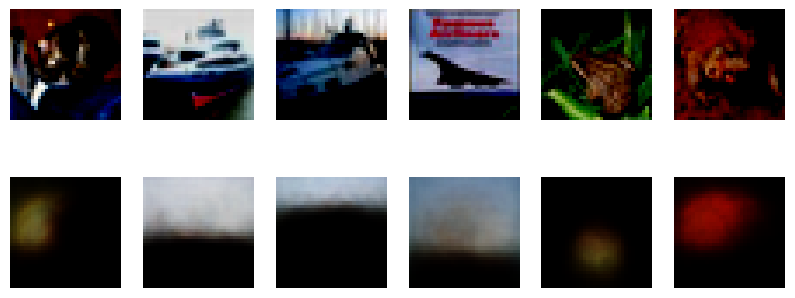

In [14]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    _, reconstructed = model(images)

images = images.view(-1,3,32,32).cpu()
reconstructed = reconstructed.view(-1,3,32,32).cpu()

plt.figure(figsize=(10,4))

for i in range(6):

    plt.subplot(2,6,i+1)
    plt.imshow(np.transpose(images[i], (1,2,0)))
    plt.axis('off')

    plt.subplot(2,6,i+7)
    plt.imshow(np.transpose(reconstructed[i], (1,2,0)))
    plt.axis('off')

plt.show()